In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
dictionary=pd.read_csv('data/data_dictionary.csv')
product_info=pd.read_csv('data/products.csv')
orders= pd.read_csv('data/orders.csv')     
order_items= pd.read_csv('data/order_items.csv')
refund_table=pd.read_csv('data/order_item_refunds.csv')
pageviews=pd.read_csv('data/website_pageviews.csv')
sessions=pd.read_csv('data/website_sessions.csv')

In [3]:
dictionary

,Table,Field,Description
0,orders,order_id,Unique identifier for each order (PK)
1,orders,created_at,Timestamp when the order was placed
2,orders,website_session_id,Unique identifier for the website session (FK)
3,orders,user_id,Unique identifier for the user (FK)
4,orders,primary_product_id,Unique identifier for the primary product in t...
5,orders,items_purchased,Number of items in the order
6,orders,price_usd,Total price for the items in the order
7,orders,cogs_usd,Cost of goods sold for the items in the order
8,order_items,order_item_id,Unique identifier for each order item (PK)
9,order_items,created_at,Timestamp when the order was placed


In [4]:
product_info.dtypes

product_id       int64
created_at      object
product_name    object
dtype: object

In [5]:
orders

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49
...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49


In [6]:
orders.columns

Index(['order_id', 'created_at', 'website_session_id', 'user_id',
       'primary_product_id', 'items_purchased', 'price_usd', 'cogs_usd'],
      dtype='object')

## Product Information

In [7]:
product_info

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


In [8]:
orders.isnull().sum()

order_id              0
created_at            0
website_session_id    0
user_id               0
primary_product_id    0
items_purchased       0
price_usd             0
cogs_usd              0
dtype: int64

In [9]:
orders.dtypes

order_id                int64
created_at             object
website_session_id      int64
user_id                 int64
primary_product_id      int64
items_purchased         int64
price_usd             float64
cogs_usd              float64
dtype: object

In [10]:
orders

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49
...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49


In [11]:
sales=orders["price_usd"].sum()
sales

1938509.7500000002

### Average Order Value

In [12]:
average_order_value = orders["price_usd"].mean()
average_order_value

59.99163649305234

In [13]:
order_items

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49
...,...,...,...,...,...,...,...
40020,40021,2015-03-19 04:10:43,32310,4,1,29.99,9.49
40021,40022,2015-03-19 05:27:28,32311,2,1,59.99,22.49
40022,40023,2015-03-19 05:27:28,32311,4,0,29.99,9.49
40023,40024,2015-03-19 05:35:57,32312,4,1,29.99,9.49


In [14]:
order_items.columns

Index(['order_item_id', 'created_at', 'order_id', 'product_id',
       'is_primary_item', 'price_usd', 'cogs_usd'],
      dtype='object')

In [15]:
order_items.isnull().sum()

order_item_id      0
created_at         0
order_id           0
product_id         0
is_primary_item    0
price_usd          0
cogs_usd           0
dtype: int64

In [16]:
order_items.dtypes

order_item_id        int64
created_at          object
order_id             int64
product_id           int64
is_primary_item      int64
price_usd          float64
cogs_usd           float64
dtype: object

In [17]:
total_orders=order_items.order_item_id.nunique()
total_orders

40025

## Units Sold Per Product

In [18]:
product_sales =order_items.groupby("product_id").size().reset_index(name="total_units_sold").sort_values("total_units_sold", ascending=False)
product_sales

,product_id,total_units_sold
0,1,24226
1,2,5796
3,4,5018
2,3,4985


Units Sold per product

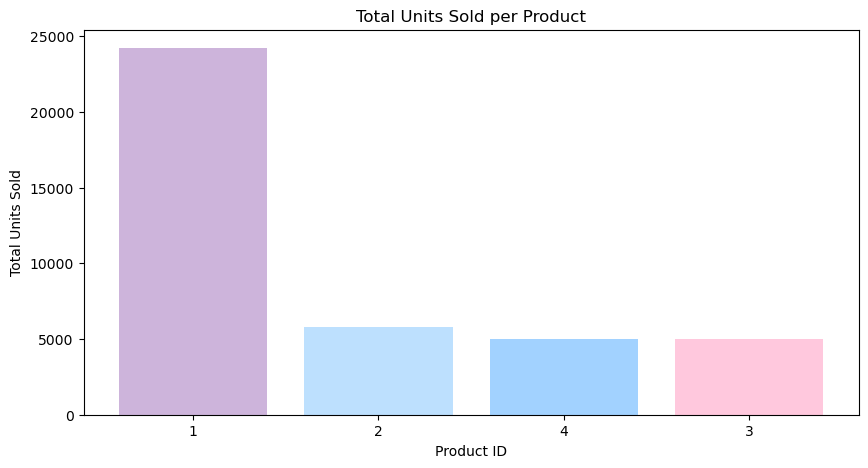

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(product_sales["product_id"].astype(str), product_sales["total_units_sold"],color=['#cdb4db', '#bde0fe', '#a2d2ff', '#ffc8dd'])
plt.xlabel("Product ID")
plt.ylabel("Total Units Sold")
plt.title("Total Units Sold per Product")
plt.show()


**Insights:**
- The visualization highlights differences across categories or time periods.
- Certain segments contribute more significantly to overall performance.
- Noticeable trends indicate periods of higher or lower activity.
- These patterns help support data‑driven decisions and improve business understanding.


In [20]:
order_items['price_usd'].unique()

array([49.99, 59.99, 45.99, 29.99])

### Unique price per Product

In [21]:
order_items.groupby("product_id")["price_usd"].unique()


product_id
1    [49.99]
2    [59.99]
3    [45.99]
4    [29.99]
Name: price_usd, dtype: object

## product Combinations

In [22]:
product_pairs = order_items.merge(order_items, on="order_id")


In [23]:
product_pairs = product_pairs[
    product_pairs["product_id_x"] != product_pairs["product_id_y"]
]


In [24]:
product_pairs["pair"] = product_pairs.apply(
    lambda row: "-".join(sorted([str(row["product_id_x"]), str(row["product_id_y"])])),
    axis=1
)


In [25]:
pair_counts = (
    product_pairs.groupby("pair")
    .size()
    .reset_index(name="times_bought_together")
    .sort_values("times_bought_together", ascending=False)
)
pair_counts

,pair,times_bought_together
2,1-4,6284
1,1-3,4072
0,1-2,1888
4,2-4,1360
5,3-4,1324
3,2-3,496


In [26]:
refund_table

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
0,1,2012-04-06 11:32:43,57,57,49.99
1,2,2012-04-13 01:09:43,74,74,49.99
2,3,2012-04-15 07:03:48,71,71,49.99
3,4,2012-04-17 20:00:37,118,118,49.99
4,5,2012-04-22 20:53:49,116,116,49.99
...,...,...,...,...,...
1726,1727,2015-03-30 09:37:23,39950,32255,59.99
1727,1728,2015-03-30 21:33:51,39671,32049,49.99
1728,1729,2015-03-31 19:59:48,39729,32090,49.99
1729,1730,2015-04-01 03:54:48,39717,32079,59.99


In [27]:
refund_table.columns

Index(['order_item_refund_id', 'created_at', 'order_item_id', 'order_id',
       'refund_amount_usd'],
      dtype='object')

In [28]:
total_refund=refund_table["order_item_id"].nunique()
total_refund

1731

In [29]:
actual_orders=total_orders-total_refund
actual_orders

38294

In [30]:
refund_amt=refund_table["refund_amount_usd"].sum()
refund_amt

85338.69

### Average Refund

In [31]:
refund_mean=refund_table["refund_amount_usd"].mean()
refund_mean

49.3002253032929

In [32]:
refunds_per_order = (refund_table.groupby("order_id")["refund_amount_usd"].sum().reset_index(name="total_refunded_usd"))
refunds_per_order

,order_id,total_refunded_usd
0,57,49.99
1,71,49.99
2,74,49.99
3,116,49.99
4,118,49.99
...,...,...
1718,32152,49.99
1719,32156,45.99
1720,32191,49.99
1721,32252,45.99


In [33]:
cogs_per_order = (order_items.groupby("order_item_id")["cogs_usd"].sum().reset_index(name="total_cogs_usd"))
cogs_per_order

,order_item_id,total_cogs_usd
0,1,19.49
1,2,19.49
2,3,19.49
3,4,19.49
4,5,19.49
...,...,...
40020,40021,9.49
40021,40022,22.49
40022,40023,9.49
40023,40024,9.49


## Refunds Merged with Order Items

In [34]:
refunds_items = pd.merge( refund_table, order_items, on="order_item_id")
refunds_items


,order_item_refund_id,created_at_x,order_item_id,order_id_x,refund_amount_usd,created_at_y,order_id_y,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-04-06 11:32:43,57,57,49.99,2012-03-31 02:32:43,57,1,1,49.99,19.49
1,2,2012-04-13 01:09:43,74,74,49.99,2012-04-03 19:09:43,74,1,1,49.99,19.49
2,3,2012-04-15 07:03:48,71,71,49.99,2012-04-03 15:03:48,71,1,1,49.99,19.49
3,4,2012-04-17 20:00:37,118,118,49.99,2012-04-15 09:00:37,118,1,1,49.99,19.49
4,5,2012-04-22 20:53:49,116,116,49.99,2012-04-13 14:53:49,116,1,1,49.99,19.49
...,...,...,...,...,...,...,...,...,...,...,...
1726,1727,2015-03-30 09:37:23,39950,32255,59.99,2015-03-18 10:37:23,32255,2,1,59.99,22.49
1727,1728,2015-03-30 21:33:51,39671,32049,49.99,2015-03-15 15:33:51,32049,1,1,49.99,19.49
1728,1729,2015-03-31 19:59:48,39729,32090,49.99,2015-03-16 10:59:48,32090,1,1,49.99,19.49
1729,1730,2015-04-01 03:54:48,39717,32079,59.99,2015-03-16 08:54:48,32079,2,0,59.99,22.49


In [35]:
refund_counts = refunds_items.groupby('product_id')['order_item_id'].count().reset_index()
refund_counts.columns = ['product_id', 'total_refunds']

### Total refunds per product

In [36]:
refund_counts

,product_id,total_refunds
0,1,1237
1,2,129
2,3,301
3,4,64


In [37]:
prod_refund = pd.merge( refund_counts, product_sales, on="product_id")
prod_refund

,product_id,total_refunds,total_units_sold
0,1,1237,24226
1,2,129,5796
2,3,301,4985
3,4,64,5018


### Refund Rate

In [38]:
prod_refund["refund_rate_%"]=(prod_refund['total_refunds']/prod_refund['total_units_sold'])*100

In [39]:
prod_refund

,product_id,total_refunds,total_units_sold,refund_rate_%
0,1,1237,24226,5.106084
1,2,129,5796,2.225673
2,3,301,4985,6.038114
3,4,64,5018,1.275409


Total refunds per product

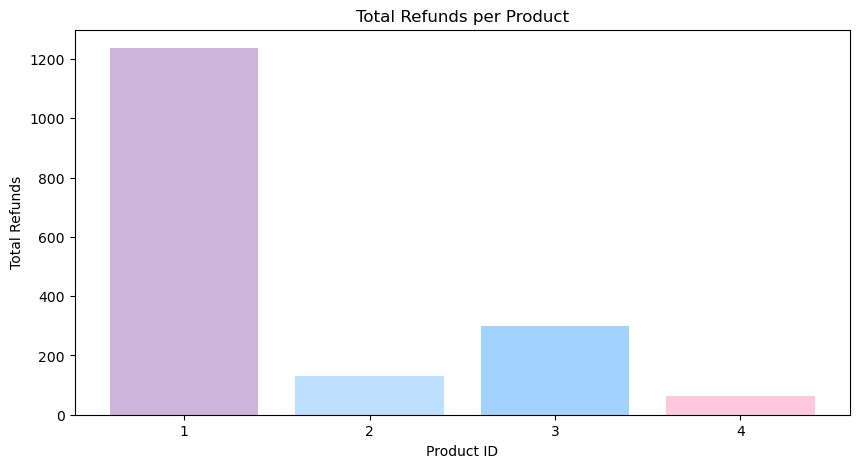

In [40]:
plt.figure(figsize=(10,5))
plt.bar(refund_counts['product_id'].astype(str), refund_counts['total_refunds'],color=['#cdb4db', '#bde0fe', '#a2d2ff', '#ffc8dd'])
plt.xlabel("Product ID")
plt.ylabel("Total Refunds")
plt.title("Total Refunds per Product")
plt.show()

**Insights:**
- The visualization highlights differences across categories or time periods.
- Certain segments contribute more significantly to overall performance.
- Noticeable trends indicate periods of higher or lower activity.
- These patterns help support data‑driven decisions and improve business understanding.


In [41]:
sales_per_product = order_items.groupby('product_id')['price_usd'].sum().reset_index()
sales_per_product.columns = ['product_id', 'sales_revenue']
sales_per_product 

,product_id,sales_revenue
0,1,1211057.74
1,2,347702.04
2,3,229260.15
3,4,150489.82


Total Sales per product

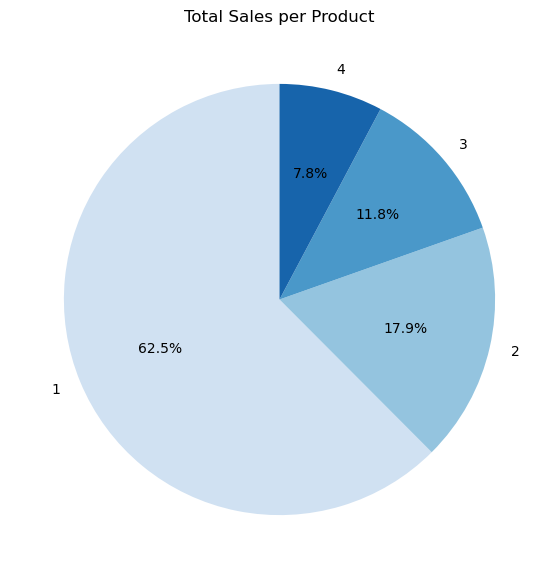

In [42]:
colors = sns.color_palette("Blues", len(sales_per_product))
plt.figure(figsize=(7,7))
plt.pie(sales_per_product['sales_revenue'],labels=sales_per_product['product_id'].astype(str),autopct='%1.1f%%',startangle=90,colors=colors)
plt.title("Total Sales per Product")
plt.show()


**INSIGHTS:**
* Product 1 generates the largest share of sales, accounting for roughly 62% of the total revenue.
* Product 2 contributes a much smaller portion, making up around 18% of overall sales.
* Product 3 represents approximately 12% of the total sales volume.
* Product 4 records the lowest contribution, with only about 8% of sales.
* Overall, the sales distribution shows a strong reliance on Product 1, while the remaining three products together contribute around 38% of total sales.

In [43]:
refund_per_product = refunds_items.groupby('product_id')['refund_amount_usd'].sum().reset_index()


In [44]:
refund_per_product

,product_id,refund_amount_usd
0,1,61837.63
1,2,7738.71
2,3,13842.99
3,4,1919.36


Refund Amount per product

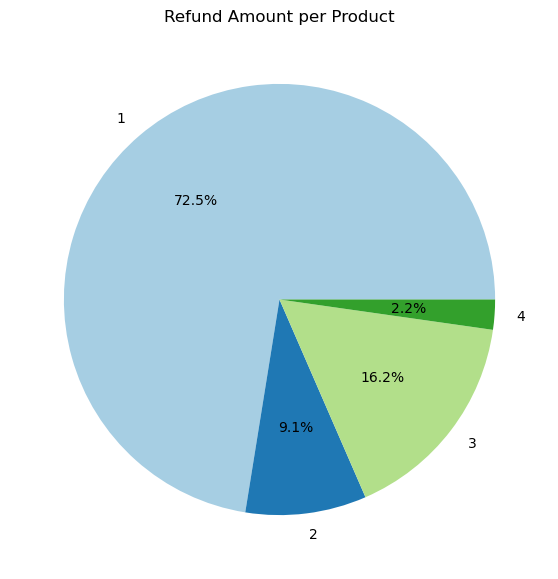

In [45]:
plt.figure(figsize=(7,7))

plt.pie(
    refund_per_product['refund_amount_usd'],
    labels=refund_per_product['product_id'].astype(str),
    autopct='%1.1f%%',
    colors=sns.color_palette("Paired", len(refund_per_product))
)

plt.title("Refund Amount per Product")
plt.show()

**INSIGHTS:**
* Product 1 records the largest share of refunds, accounting for nearly 72% of the total refund value.
* Product 3 contributes the second highest portion, representing roughly 16% of overall refunds.
* Product 2 is responsible for a smaller share, making up about 9% of the total refund amount.
* Product 4 shows minimal refund activity, contributing only around 2%.
* The refund distribution is heavily concentrated in Product 1, suggesting possible issues related to product quality, customer expectations, or order fulfillment for this product.

In [46]:
prod_info=pd.merge(sales_per_product,refund_per_product,on='product_id')

In [47]:
prod_info

,product_id,sales_revenue,refund_amount_usd
0,1,1211057.74,61837.63
1,2,347702.04,7738.71
2,3,229260.15,13842.99
3,4,150489.82,1919.36


In [48]:
prod_info['net_revenue'] = prod_info['sales_revenue'] - prod_info['refund_amount_usd']



In [49]:
prod_info

,product_id,sales_revenue,refund_amount_usd,net_revenue
0,1,1211057.74,61837.63,1149220.11
1,2,347702.04,7738.71,339963.33
2,3,229260.15,13842.99,215417.16
3,4,150489.82,1919.36,148570.46


## Total net revenue

In [50]:
prod_info['net_revenue'].sum()

1853171.06

C:\Users\Admin\AppData\Local\Temp\ipykernel_38320\4059377519.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( data=prod_info, x='product_id', y='net_revenue', palette='Paired')


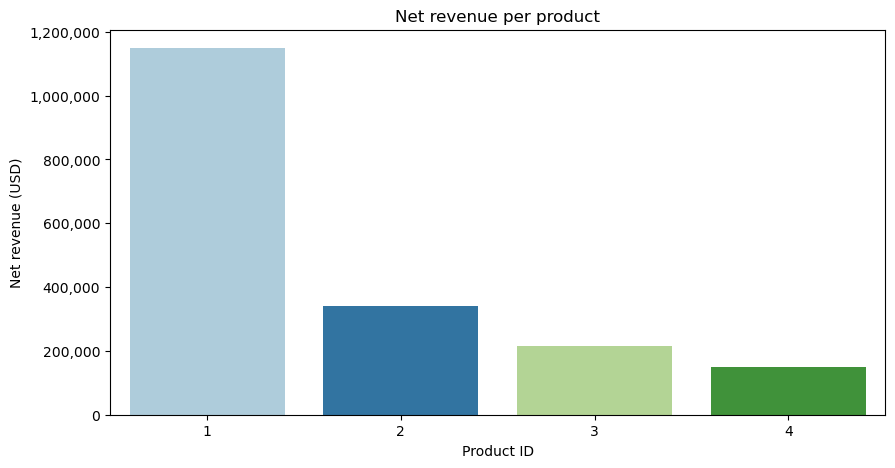

In [51]:
plt.figure(figsize=(10,5))
sns.barplot( data=prod_info, x='product_id', y='net_revenue', palette='Paired')
plt.xlabel("Product ID")
plt.ylabel("Net revenue (USD)")
plt.title("Net revenue per product")
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()

**INSIGHTS:**
* Product 1 generates the highest net revenue, about $1.15 million.

* Product 2 generates around $0.34 million in net revenue.

* Product 3 contributes about $0.21 million in net revenue.

* Product 4 has the lowest net revenue, around $0.15 million.

* There is a very large gap between Product 1 and the other products.

* Net revenue is mainly driven by Product 1, while Products 3 and 4 contribute much less

## Customer Lifecycle Analysis

# Overall Trends

In [52]:
user_orders = orders.groupby("user_id")["order_id"].count().reset_index()
user_orders.columns = ["user_id", "total_orders"]


In [53]:
orders["created_at"] = pd.to_datetime(orders["created_at"])


In [54]:
orders

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49
...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49


In [55]:
orders['created_at'].dt.year.unique()


array([2012, 2013, 2014, 2015])

In [56]:
yearly_orders = orders.groupby(orders['created_at'].dt.year).size().reset_index(name="Sales_per_year")
yearly_orders


,created_at,Sales_per_year
0,2012,2586
1,2013,7447
2,2014,16860
3,2015,5420


Total orders per year

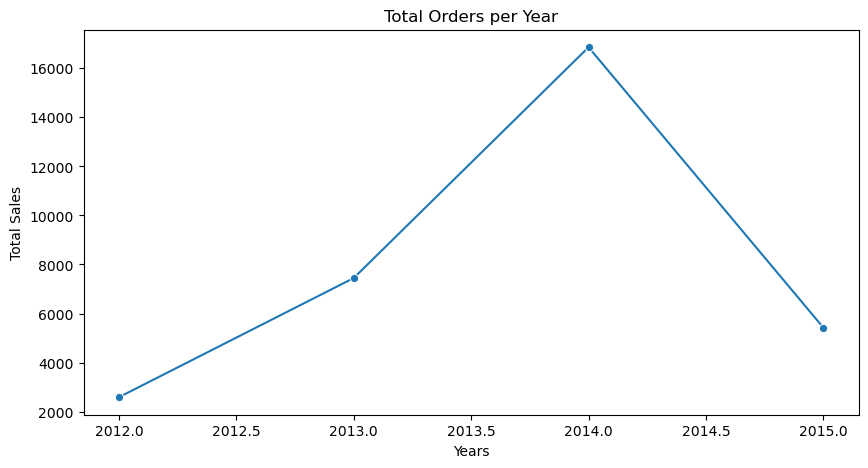

In [57]:
plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_orders, x='created_at', y='Sales_per_year', marker='o')
plt.xlabel("Years")
plt.ylabel("Total Sales")
plt.title("Total Orders per Year")
plt.show()


**INSIGHTS:**
* Total orders rose from roughly 2,600 in 2012 to about 7,400 in 2013.
* The number of orders peaked in 2014, reaching nearly 16,900 orders, which is the highest in the given period.
* In 2015, the order count decreased significantly to around 5,500.
* Overall, the data indicates a steady increase in orders from 2012 to 2014, followed by a sharp decline in 2015.
* Among all the years, 2014 recorded the highest order volume, while 2012 had the lowest number of orders.

In [58]:
Monthly_orders = orders.groupby(orders['created_at'].dt.month).size().reset_index(name="Orders_per_Month")
Monthly_orders

,created_at,Orders_per_Month
0,1,3470
1,2,3587
2,3,2765
3,4,1893
4,5,2047
5,6,1972
6,7,2059
7,8,2161
8,9,2340
9,10,2688


Total orders per month

C:\Users\Admin\AppData\Local\Temp\ipykernel_38320\453646576.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=Monthly_orders,x='created_at',y='Orders_per_Month',palette='mako')


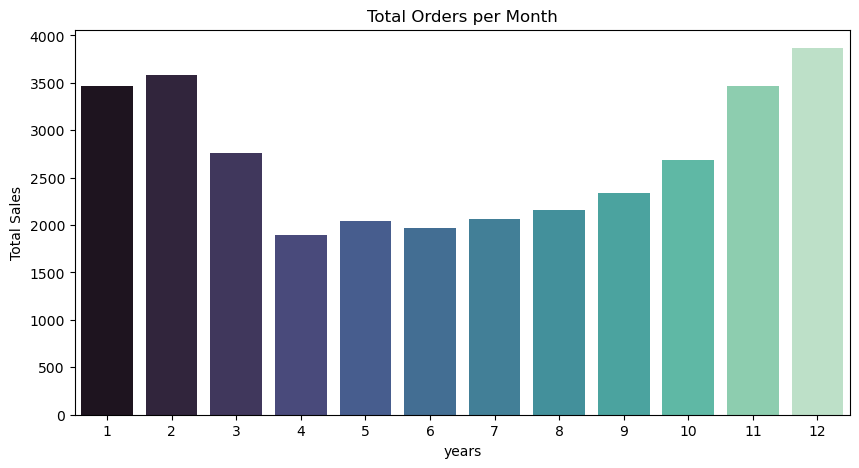

In [59]:
plt.figure(figsize=(10,5))
sns.barplot(data=Monthly_orders,x='created_at',y='Orders_per_Month',palette='mako')
plt.xlabel("years")
plt.ylabel("Total Sales")
plt.title("Total Orders per Month")
plt.show()

**INSIGHTS:**
* Orders are high at the beginning of the year, with about 3,500 in January and 3,600 in February.
* Orders drop in April to around 1,900, which is one of the lowest months.
* From May to August, orders stay almost stable between 2,000 and 2,200.
* Orders start increasing again from September (~2,350).
* The highest orders are seen in December with about 3,900 orders.
* Overall, there is a dip in mid-year (April–June) and a strong rise towards the end of the year (Oct–Dec).

In [60]:
weekly_orders = orders.groupby(orders['created_at'].dt.day_name()).size()
weekly_orders

created_at
Friday       5571
Monday       5662
Saturday     2309
Sunday       2538
Thursday     5414
Tuesday      5320
Wednesday    5499
dtype: int64

Week-wise orders trend

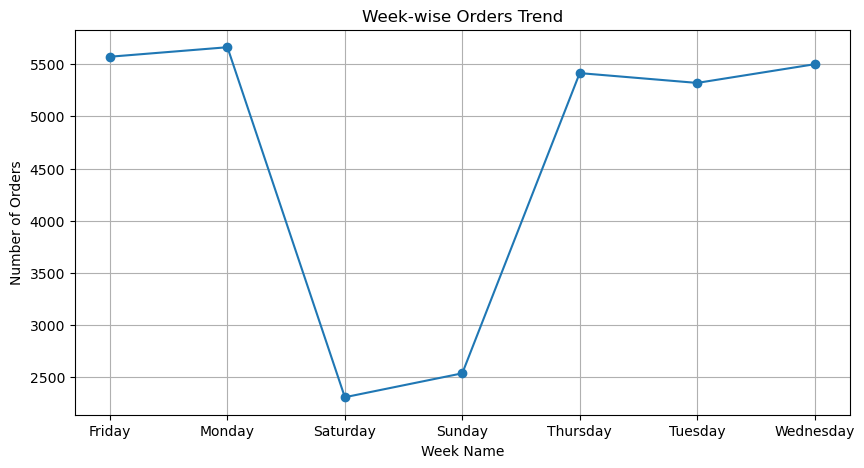

In [61]:
plt.figure(figsize=(10,5))         
plt.plot(weekly_orders, marker='o') 
plt.title("Week-wise Orders Trend")
plt.xlabel("Week Name")
plt.ylabel("Number of Orders")
plt.grid(True)                    
plt.show()


**INSIGHTS:**
* Monday has the highest orders (~5,650–5,700).
* Friday and Wednesday are also high (~5,500+).
* Tuesday and Thursday are stable (~5,300–5,400).
* Saturday has the lowest orders (~2,300).
* Sunday is slightly better than Saturday (~2,500).

In [62]:
hourly_orders = orders.groupby(orders['created_at'].dt.hour).size()
hourly_orders

created_at
0      823
1      721
2      586
3      546
4      549
5      566
6      684
7      756
8     1149
9     1661
10    1948
11    2194
12    2172
13    2085
14    2153
15    2188
16    2099
17    1922
18    1593
19    1378
20    1189
21    1192
22    1131
23    1028
dtype: int64

Orders by time of day

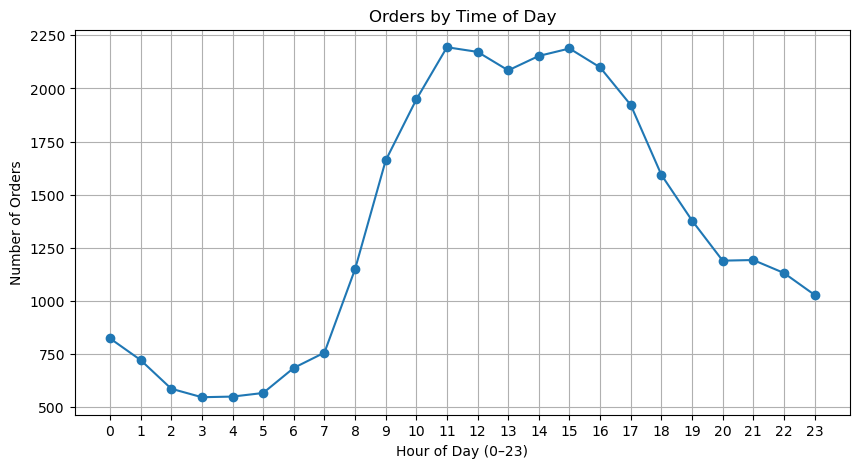

In [63]:
plt.figure(figsize=(10,5))
plt.plot(hourly_orders, marker='o')
plt.title("Orders by Time of Day")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Orders")
plt.grid(True)
plt.xticks(range(24))
plt.show()

**INSIGHTS:**
* Order activity is lowest during the early morning hours (3 AM–5 AM), with roughly 550–600 orders.
* The number of orders begins to rise after 7 AM, reaching around 750 orders, and increases rapidly between 8 AM and 10 AM.
* The highest order volume occurs between 11 AM and 3 PM, with peaks of nearly 2,200 orders around 11 AM and 3 PM.
* Order levels remain relatively high until about 4 PM, with approximately 2,100 orders.
* After 5 PM, the order volume gradually declines as the evening progresses.

## Refund Trend

In [64]:
refund_table["created_at"] = pd.to_datetime(refund_table["created_at"])

In [65]:
Yearly_Refund_orders = refund_table.groupby(refund_table['created_at'].dt.year).size().reset_index(name="Refunds_per_Year")
Yearly_Refund_orders

,created_at,Refunds_per_Year
0,2012,169
1,2013,339
2,2014,960
3,2015,263


Total refunds per year

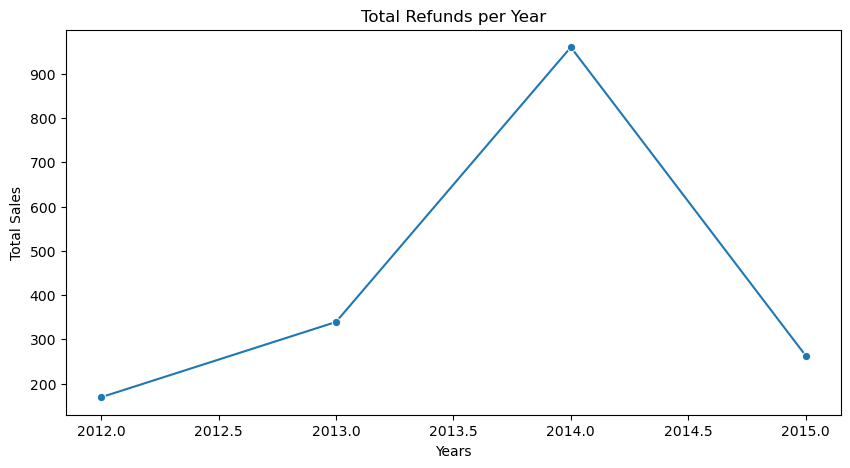

In [66]:
plt.figure(figsize=(10,5))
sns.lineplot(data=Yearly_Refund_orders, x='created_at', y='Refunds_per_Year', marker='o')
plt.xlabel("Years")
plt.ylabel("Total Sales")
plt.title("Total Refunds per Year")
plt.show()


**INSIGHTS:**
* The number of refunds gradually increased between 2012 and 2014, with a noticeable surge in 2014.
* The sharp rise in 2014 could be linked to higher sales volume or potential issues related to products or services.
* In 2015, the refund count dropped significantly, which may indicate better product quality, improved customer satisfaction, or more effective refund management.

In [67]:
Monthly_Refund_orders = refund_table.groupby(refund_table['created_at'].dt.to_period('M')).size().reset_index(name="Refunds_per_Month")
Monthly_Refund_orders

,created_at,Refunds_per_Month
0,2012-04,5
1,2012-05,5
2,2012-06,5
3,2012-07,13
4,2012-08,18
5,2012-09,21
6,2012-10,24
7,2012-11,40
8,2012-12,38
9,2013-01,21


In [68]:
Monthly_Refund_orders1=refund_table.groupby(refund_table['created_at'].dt.month).size().reset_index(name="Refunds_per_Month")
Monthly_Refund_orders1

,created_at,Refunds_per_Month
0,1,157
1,2,151
2,3,148
3,4,85
4,5,87
5,6,108
6,7,136
7,8,146
8,9,282
9,10,103


Total refunds per month

C:\Users\Admin\AppData\Local\Temp\ipykernel_38320\4045890746.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=Monthly_Refund_orders1,x='created_at',y='Refunds_per_Month',palette='summer')


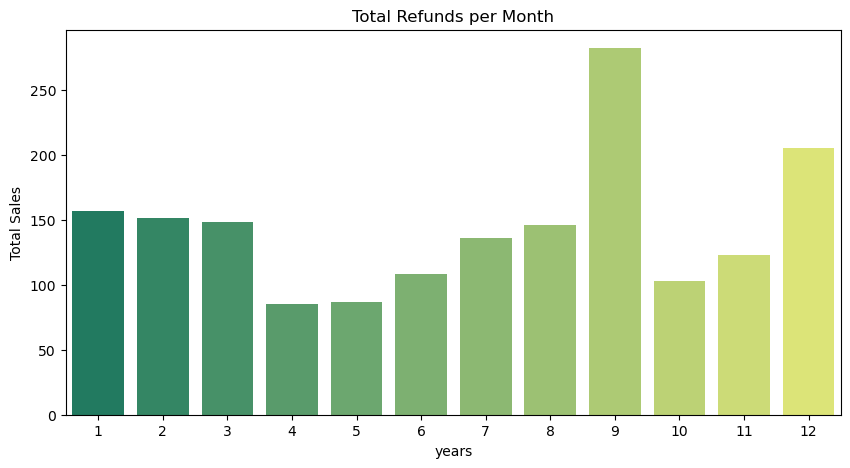

In [69]:
plt.figure(figsize=(10,5))
sns.barplot(data=Monthly_Refund_orders1,x='created_at',y='Refunds_per_Month',palette='summer')
plt.xlabel("years")
plt.ylabel("Total Sales")
plt.title("Total Refunds per Month")
plt.show()

**INSIGHTS:**
* Refund levels decline from Month 1 to Month 4, showing a downward trend during the early part of the year.
* Following Month 4, the number of refunds gradually increases up to Month 9.
* A significant peak occurs in Month 9, recording the highest refund count of the year.
* After this peak, refunds drop in Month 10, but then rise again as the year approaches Month 12.

# Customer Lifecycle & Repeat Behaviour 

## Order Frequeny

In [70]:
orders_per_user = orders.groupby('user_id')['order_id'].nunique().reset_index()
orders_per_user.columns = ['user_id', 'order_count']

In [71]:
def Order_Quantity(i):
    if i == 1:
        return '1 order'
    elif i == 2:
        return '2 orders'
    else:
        return '3+ orders'

orders_per_user['order_group'] = orders_per_user['order_count'].apply(Order_Quantity)

In [72]:
order_dist = orders_per_user['order_group'].value_counts().reset_index()
order_dist.columns = ['order_group', 'num_users']

Order frequency per user`

In [73]:
import plotly.express as px

px.bar(order_dist,
       x='order_group',
       y='num_users',
       text='num_users',
       title='Order Frequency per User').show()

**Insights:**
- The visualization highlights differences across categories or time periods.
- Certain segments contribute more significantly to overall performance.
- Noticeable trends indicate periods of higher or lower activity.
- These patterns help support data‑driven decisions and improve business understanding.


In [74]:
orders['order_month'] = orders['created_at'].dt.to_period('M').astype(str)

In [75]:
first_purchase = orders.groupby('user_id')['order_month'].min().reset_index()
first_purchase.columns = ['user_id', 'cohort_month']

In [76]:
first_purchase

,user_id,cohort_month
0,13,2012-04
1,20,2012-03
2,59,2012-04
3,104,2012-03
4,147,2012-03
...,...,...
31691,394231,2015-03
31692,394255,2015-03
31693,394257,2015-03
31694,394268,2015-03


In [77]:
Orders1 = orders.merge(first_purchase, on='user_id', how='left')
Orders1

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd,order_month,cohort_month
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49,2012-03,2012-03
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49,2012-03,2012-03
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49,2012-03,2012-03
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49,2012-03,2012-03
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49,2012-03,2012-03
...,...,...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49,2015-03,2015-03
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49,2015-03,2015-03
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98,2015-03,2015-03
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49,2015-03,2015-03


In [78]:
Orders1.dtypes

order_id                       int64
created_at            datetime64[ns]
website_session_id             int64
user_id                        int64
primary_product_id             int64
items_purchased                int64
price_usd                    float64
cogs_usd                     float64
order_month                   object
cohort_month                  object
dtype: object

In [79]:
Orders1['order_month_dt'] = pd.to_datetime(Orders1['order_month'], format='%Y-%m')
Orders1['cohort_month_dt'] = pd.to_datetime(Orders1['cohort_month'], format='%Y-%m')

In [80]:
Orders1['cohort_index'] = (
    (Orders1['order_month_dt'].dt.year - Orders1['cohort_month_dt'].dt.year) * 12 +
    (Orders1['order_month_dt'].dt.month - Orders1['cohort_month_dt'].dt.month)
)

In [81]:
cohort_data = Orders1.groupby(['cohort_month', 'cohort_index'])['user_id'].nunique().reset_index()
cohort_data 

,cohort_month,cohort_index,user_id
0,2012-03,0,60
1,2012-04,0,99
2,2012-05,0,108
3,2012-06,0,139
4,2012-06,1,1
...,...,...,...
112,2015-01,1,30
113,2015-01,2,15
114,2015-02,0,2004
115,2015-02,1,16


In [82]:
cohort_table = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='user_id'
)
cohort_table

cohort_index,0,1,2,3,4
cohort_month,,,,,
2012-03,60.0,NaN,NaN,NaN,NaN
2012-04,99.0,NaN,NaN,NaN,NaN
2012-05,108.0,NaN,NaN,NaN,NaN
2012-06,139.0,1.0,NaN,NaN,NaN
2012-07,168.0,NaN,NaN,NaN,NaN
2012-08,227.0,1.0,NaN,NaN,NaN
2012-09,286.0,1.0,3.0,NaN,NaN
2012-10,368.0,2.0,NaN,NaN,NaN
2012-11,612.0,2.0,1.0,NaN,1.0


In [83]:
Order_gap = orders.sort_values(['user_id', 'created_at'])

# difference in days between consecutive orders
Order_gap['days_gap'] = Order_gap.groupby('user_id')['created_at'].diff().dt.days

In [84]:
Order_gap= (Order_gap.groupby('user_id')['days_gap'].first() .dropna())

**Average Repurchase Cycle**


In [85]:
import plotly.express as px

fig = px.histogram(
    Order_gap,
    x=Order_gap,
    nbins=20,  # you can change number of bins
    title="Distribution of Days Between First and Second Order"
)

fig.show()

**Insights:**
- The visualization highlights differences across categories or time periods.
- Certain segments contribute more significantly to overall performance.
- Noticeable trends indicate periods of higher or lower activity.
- These patterns help support data‑driven decisions and improve business understanding.


## Customer Lifecycle Analysis

In [86]:
user_orders = orders.groupby("user_id")["order_id"].count().reset_index()
user_orders.columns = ["user_id", "total_orders"]

In [87]:
user_orders["user_type"] = "New User"
user_orders.loc[user_orders["total_orders"] > 1, "user_type"] = "Repeat User"

In [88]:
user_counts =user_orders["user_type"].value_counts()
user_counts

user_type
New User       31105
Repeat User      591
Name: count, dtype: int64

Neww vs Repeat customer

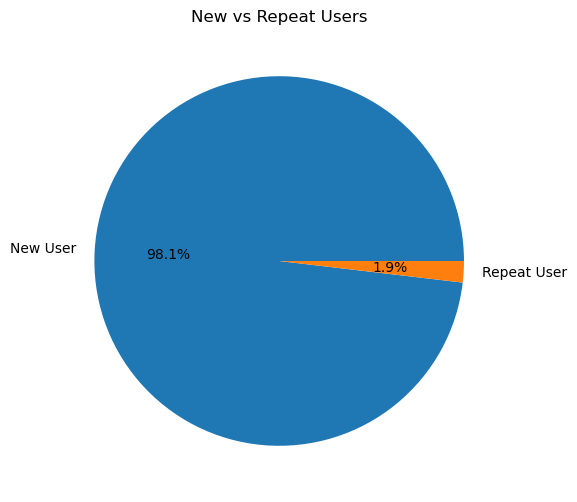

In [89]:
plt.figure(figsize=(6,6))
plt.pie(user_counts.values, labels=user_counts.index, autopct='%1.1f%%')
plt.title("New vs Repeat Users")
plt.show()

**INSIGHTS:**

* New users make up about 98% of total users.
* Repeat users are only around 2% of the total user base.
* This shows the business is getting many new customers but very few customers are returning.
* There is a huge gap between new and repeat users.
* This suggests a need to improve customer retention and loyalty programs.

In [90]:
orders_ct = orders.merge(user_orders[["user_id","user_type"]], on="user_id", how="left")

In [91]:
total_items = orders_ct.groupby("user_type")["items_purchased"].sum().reset_index(name="total_items")

In [92]:
refunds_ct = refund_table.merge(
    orders_ct[["order_id","user_type"]],
    on="order_id",
    how="left"
)

refunded_items = refunds_ct.groupby("user_type")["order_item_id"].count().reset_index(name="refunded_items")

In [93]:
summary = total_items.merge(refunded_items, on="user_type", how="left").fillna(0)

summary["refund_rate %"] = (summary["refunded_items"] / summary["total_items"]) * 100

summary = summary.set_index("user_type")
summary

,total_items,refunded_items,refund_rate %
user_type,,,
New User,38469,1662,4.320362
Repeat User,1556,69,4.434447


## REPEAT PURCHASE RATE PER PRODUCT

In [94]:
df = order_items.merge(
    orders[["order_id","user_id"]],
    on="order_id",
    how="left"
).merge(
    product_info[["product_id","product_name"]],
    on="product_id",
    how="left"
)

In [95]:
user_product = df.groupby(["product_name","user_id"]).size().reset_index(name="times_bought")

In [96]:
total_customers = user_product.groupby("product_name")["user_id"].nunique().reset_index(name="total_customers")

In [97]:
repeat_df = user_product[user_product["times_bought"] > 1]

In [98]:
repeat_customers = repeat_df.groupby("product_name")["user_id"].nunique()

In [99]:
repeat_customers = repeat_customers.reset_index()
repeat_customers.columns = ["product_name", "repeat_customers"]

In [100]:
result = total_customers.merge(repeat_customers, on="product_name", how="left").fillna(0)

result["repeat_purchase_rate_%"] = (result["repeat_customers"] / result["total_customers"]) * 100

result

,product_name,total_customers,repeat_customers,repeat_purchase_rate_%
0,The Birthday Sugar Panda,4957,27,0.544684
1,The Forever Love Bear,5776,20,0.346260
2,The Hudson River Mini bear,4982,36,0.722601
3,The Original Mr. Fuzzy,23887,326,1.364759


Repeat Purchase rate per product

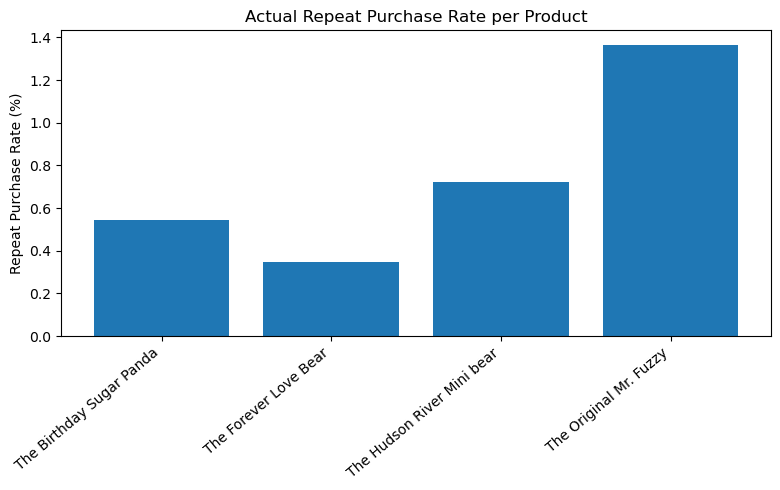

In [101]:
plt.figure(figsize=(8,5))
plt.bar(
    result['product_name'],
    result['repeat_purchase_rate_%']
)
plt.ylabel("Repeat Purchase Rate (%)")
plt.title("Actual Repeat Purchase Rate per Product")
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

**Insights:**
- The visualization highlights differences across categories or time periods.
- Certain segments contribute more significantly to overall performance.
- Noticeable trends indicate periods of higher or lower activity.
- These patterns help support data‑driven decisions and improve business understanding.


In [102]:
 orders_with_type = orders.merge(
    user_orders[['user_id', 'user_type']],
    on='user_id',
    how='left'
)
orders_with_type

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd,order_month,user_type
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49,2012-03,New User
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49,2012-03,New User
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49,2012-03,New User
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49,2012-03,New User
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49,2012-03,New User
...,...,...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49,2015-03,New User
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49,2015-03,New User
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98,2015-03,New User
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49,2015-03,New User


Order Value Distribution New vs Repeat


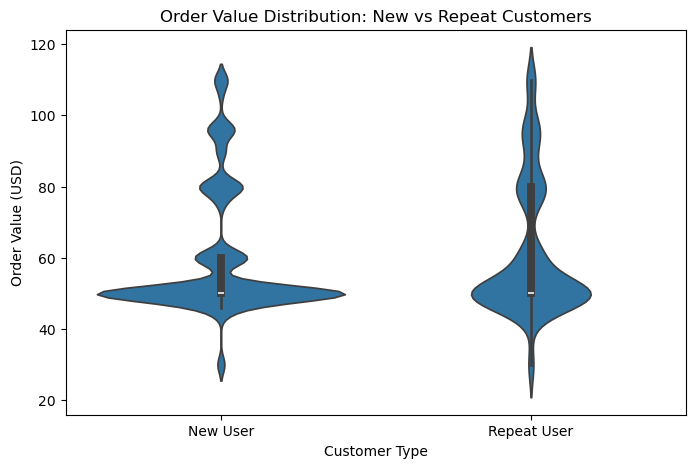

In [103]:
plt.figure(figsize=(8,5))
sns.violinplot(
    data=orders_with_type,
    x='user_type',
    y='price_usd',
    inner='box'
)
plt.title("Order Value Distribution: New vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Order Value (USD)")
plt.show()

**Insights:**
- The visualization highlights differences across categories or time periods.
- Certain segments contribute more significantly to overall performance.
- Noticeable trends indicate periods of higher or lower activity.
- These patterns help support data‑driven decisions and improve business understanding.
